In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# EDA - Visualising Missing Data

In [24]:
eden_theta = pd.read_csv("../data2/THETA_0001_F863663069837491_365days.csv")

eden_hydro = pd.read_csv("../data2/HYDRORANGER_0001_F863663062793626_365days.csv")

In [25]:
eden_theta['timestamp'] = pd.to_datetime(eden_theta['timestamp'])
eden_theta['gap'] = eden_theta['timestamp'].diff().dt.total_seconds() / 60
eden_theta['gap'].describe()

count    34272.000000
mean        15.012255
std          1.566933
min         15.000000
25%         15.000000
50%         15.000000
75%         15.000000
max        270.000000
Name: gap, dtype: float64

In [26]:
eden_hydro['timestamp'] = pd.to_datetime(eden_hydro['timestamp'])
eden_hydro['gap'] = eden_hydro['timestamp'].diff().dt.total_seconds() / 60
eden_hydro['gap'].describe()

count    35013.000000
mean        15.011567
std          2.164414
min         15.000000
25%         15.000000
50%         15.000000
75%         15.000000
max        420.000000
Name: gap, dtype: float64

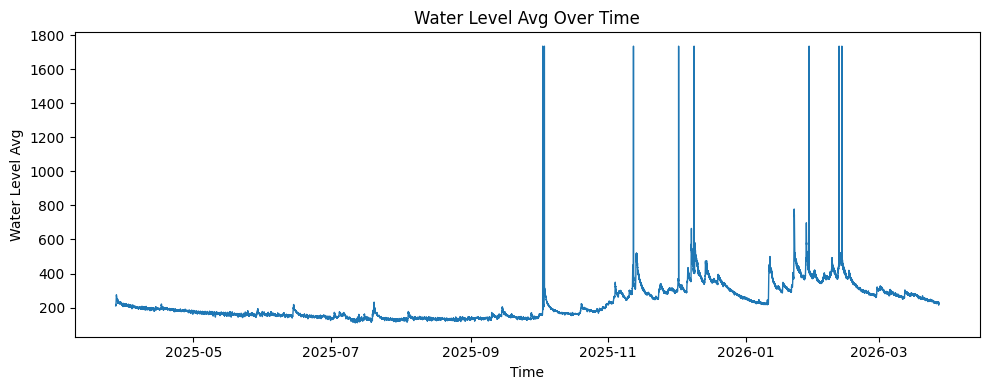

In [27]:
def plot_variable_over_time( df, variable, time_col="timestamp", title=None,figsize=(10,4)):
    """
    Plots any numeric variable against time.
    """

    # Ensure sorted by time
    df = df.sort_values(time_col)

    plt.figure(figsize=figsize)
    plt.plot(df[time_col], df[variable], label=variable, linewidth=1)

    plt.xlabel("Time")
    plt.ylabel(variable.replace("_", " ").title())
    plt.title(title if title else f"{variable.replace('_',' ').title()} Over Time")
    # plt.legend()

    plt.tight_layout()
    plt.show()

plot_variable_over_time(eden_hydro, "water_level_avg")

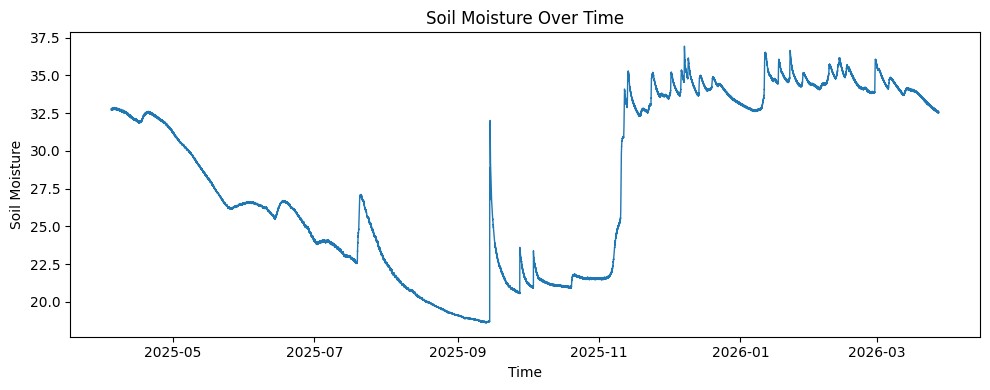

In [28]:
plot_variable_over_time(eden_theta, "soil_moisture")

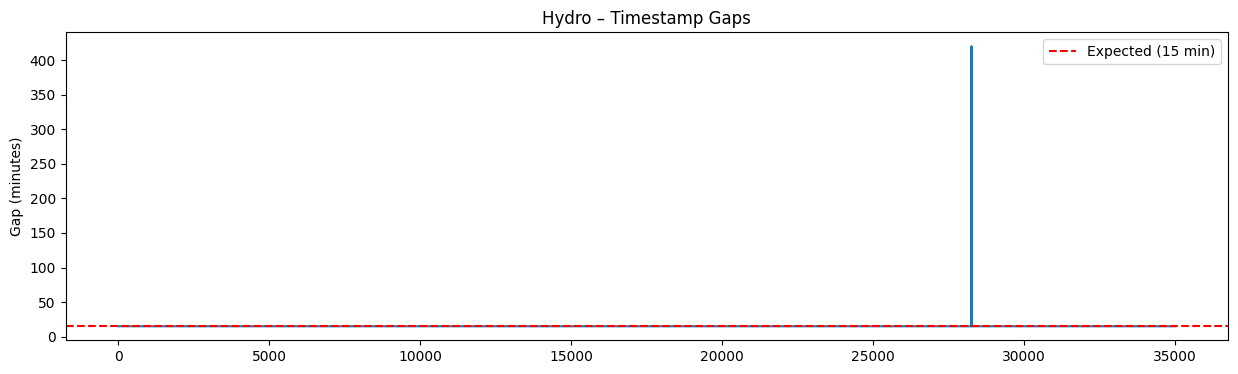

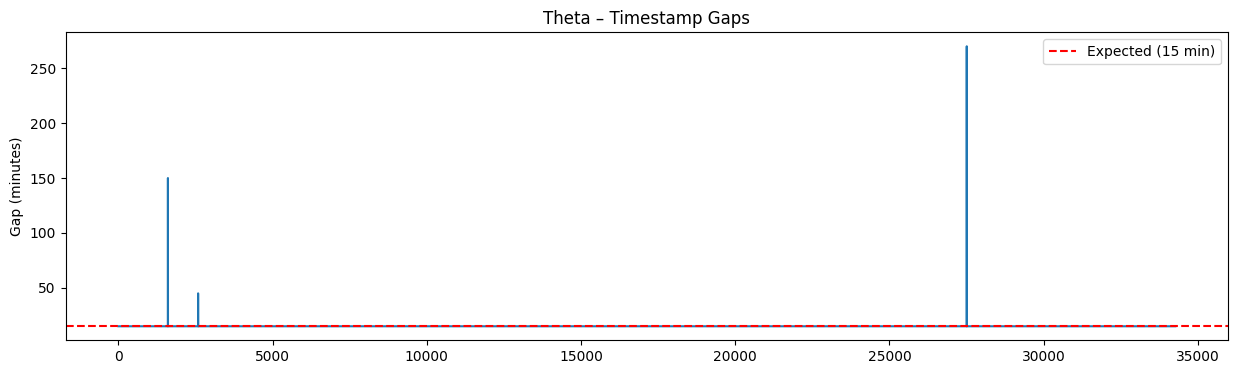

In [29]:
def plot_time_gaps(df, title):
    ts = df.set_index("timestamp").sort_index()
    dt = ts.index.to_series().diff().dt.total_seconds() / 60  # minutes
    
    plt.figure(figsize=(15,4))
    plt.plot(dt.values)
    plt.axhline(15, color="red", linestyle="--", label="Expected (15 min)")
    plt.title(title)
    plt.ylabel("Gap (minutes)")
    plt.legend()
    plt.show()

plot_time_gaps(eden_hydro, "Hydro – Timestamp Gaps")
plot_time_gaps(eden_theta, "Theta – Timestamp Gaps")

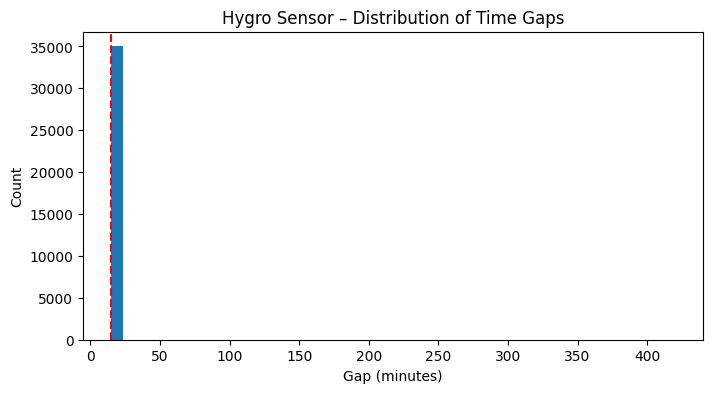

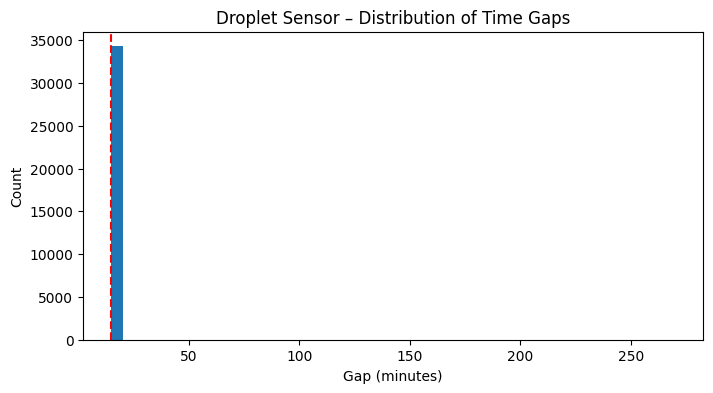

In [30]:
def hist_time_gaps(df, label):
    gaps = df.sort_values("timestamp")["timestamp"].diff().dt.total_seconds() / 60

    plt.figure(figsize=(8,4))
    plt.hist(gaps.dropna(), bins=50)
    plt.axvline(15, color="red", linestyle="--")
    plt.title(f"{label} – Distribution of Time Gaps")
    plt.xlabel("Gap (minutes)")
    plt.ylabel("Count")
    plt.show()

hist_time_gaps(eden_hydro, "Hygro Sensor")
hist_time_gaps(eden_theta, "Droplet Sensor")

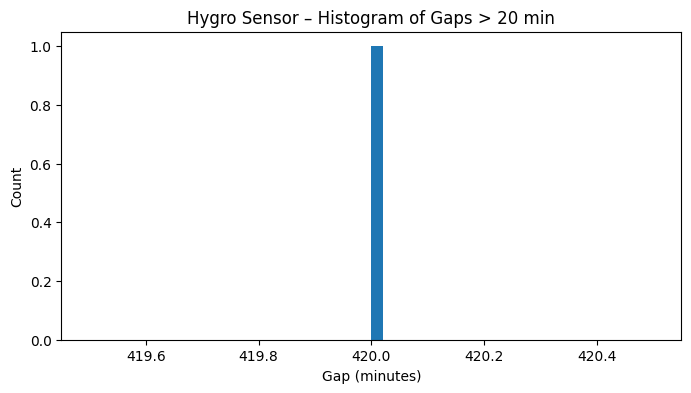

Hygro Sensor: Number of gaps > 20 minutes = 1
Min gap > 20: 420.0 min
Max gap > 20: 420.0 min
Median gap > 20: 420.0 min


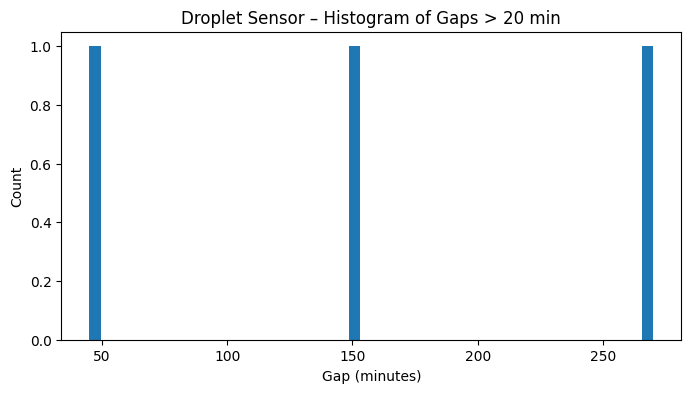

Droplet Sensor: Number of gaps > 20 minutes = 3
Min gap > 20: 45.0 min
Max gap > 20: 270.0 min
Median gap > 20: 150.0 min


In [31]:
def hist_large_gaps(df, label, threshold=20):
    # Compute gaps in minutes
    gaps = (
        df.sort_values("timestamp")["timestamp"]
        .diff()
        .dt.total_seconds() / 60
    )

    # Filter only large gaps
    large_gaps = gaps[gaps > threshold]

    plt.figure(figsize=(8,4))
    plt.hist(large_gaps, bins=50)
    plt.title(f"{label} – Histogram of Gaps > {threshold} min")
    plt.xlabel("Gap (minutes)")
    plt.ylabel("Count")
    plt.show()

    print(f"{label}: Number of gaps > {threshold} minutes = {len(large_gaps)}")
    print(f"Min gap > {threshold}: {large_gaps.min():.1f} min")
    print(f"Max gap > {threshold}: {large_gaps.max():.1f} min")
    print(f"Median gap > {threshold}: {large_gaps.median():.1f} min")

hist_large_gaps(eden_hydro, "Hygro Sensor")
hist_large_gaps(eden_theta, "Droplet Sensor")

/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_90603/3199468587.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


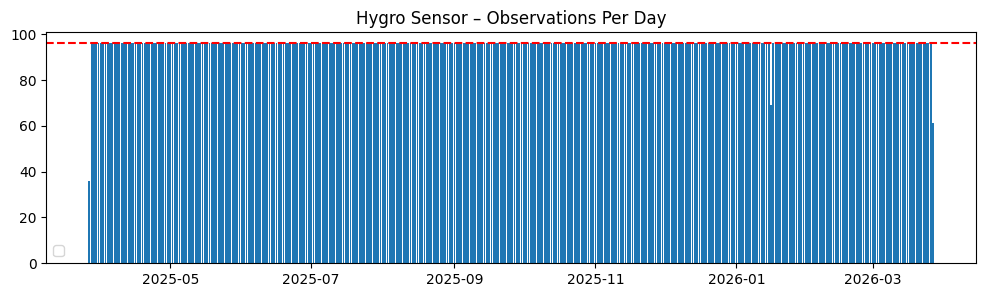

/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_90603/3199468587.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


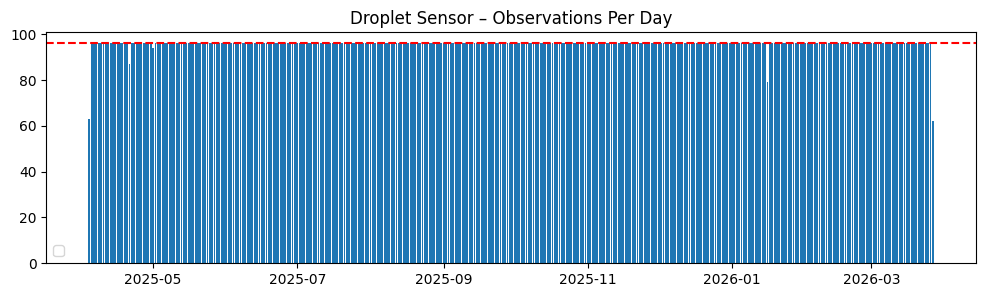

In [32]:
def plot_daily_counts(df, label):
    ts = df.set_index("timestamp").sort_index()
    counts = ts.resample("D").size()

    plt.figure(figsize=(12,3))
    plt.bar(counts.index, counts.values)
    plt.axhline(24*4, color="red", linestyle="--")
    plt.title(f"{label} – Observations Per Day")
    plt.legend()
    plt.show()

plot_daily_counts(eden_hydro, "Hygro Sensor")
plot_daily_counts(eden_theta, "Droplet Sensor")

## Heatmaps to observe whether there is correlation between missing data and the features

In [33]:
eden_theta

,timestamp,device_eui,device_name,device_type,site_name,latitude,longitude,payload,metadata,soil_moisture,soil_temp,soil_conductivity,gap
0,2025-04-04 08:15:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633382e30372b382e352b3236,"{'ver': '1.2.0', 'battV': 3.3, 'signal': 28, '...",32.77,8.5,26.0,NaN
1,2025-04-04 08:30:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633372e37322b382e352b3236,"{'imei': 'F901405112736288', 'ver': '1.2.0', '...",32.76,8.5,26.0,15.0
2,2025-04-04 08:45:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633362e37342b382e342b3236,"{'ver': '1.2.0', 'battV': 3.3, 'signal': 28, '...",32.72,8.4,26.0,15.0
3,2025-04-04 09:00:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633382e31352b382e342b3236,"{'ver': '1.2.0', 'battV': 3.3, 'signal': 27, '...",32.77,8.4,26.0,15.0
4,2025-04-04 09:15:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633372e38392b382e342b3236,"{'imei': 'F901405112736288', 'ver': '1.2.0', '...",32.76,8.4,26.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34268,2026-03-27 14:15:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633312e34392b362e382b3239,"{'imei': 'F901405112736288', 'ver': '1.2.1', '...",32.52,6.8,29.0,15.0
34269,2026-03-27 14:30:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633312e34352b362e382b3239,"{'imei': 'F901405112736288', 'ver': '1.2.1', '...",32.51,6.8,29.0,15.0
34270,2026-03-27 14:45:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633322e39382b362e392b3239,"{'imei': 'F901405112736288', 'ver': '1.2.1', '...",32.57,6.9,29.0,15.0
34271,2026-03-27 15:00:00+00:00,F863663069837491,THETA #0001,Theta,Barroway Burn at Demperston Farm,56.284666,-3.256403,302b323633312e34322b362e392b3239,"{'imei': 'F901405112736288', 'ver': '1.2.1', '...",32.51,6.9,29.0,15.0


In [34]:
eden_hydro

,timestamp,device_eui,device_name,device_type,site_name,latitude,longitude,payload,metadata,sensors,water_level_avg,water_level_min,water_level_max,air_temp,air_humidity,gap
0,2025-03-27 15:00:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507ea07e607eb045722e8fc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 28, ...",5.0,210.0,209.0,214.0,11.11,89.36,NaN
1,2025-03-27 15:15:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507e707e507e8044e22f2fc88,"{'ver': '1.0.8', 'battV': 3.32, 'signal': 28, ...",5.0,213.0,212.0,215.0,11.02,89.46,15.0
2,2025-03-27 15:30:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507e607e207e9043b22cffc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 28, ...",5.0,214.0,211.0,218.0,10.83,89.11,15.0
3,2025-03-27 15:45:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507e407e207e70437232efc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 28, ...",5.0,216.0,213.0,218.0,10.79,90.06,15.0
4,2025-03-27 16:00:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507e607e207e70434233bfc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 27, ...",5.0,214.0,213.0,218.0,10.76,90.19,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35009,2026-03-27 14:00:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507e407de07e6030c1e76fc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 24, ...",5.0,216.0,214.0,222.0,7.80,77.98,15.0
35010,2026-03-27 14:15:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507dd07db07de02dd1f48fc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 24, ...",5.0,223.0,222.0,225.0,7.33,80.08,15.0
35011,2026-03-27 14:30:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507d907d807db03271edcfc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 24, ...",5.0,227.0,225.0,228.0,8.07,79.00,15.0
35012,2026-03-27 14:45:00+00:00,F863663062793626,HYDRORANGER #0001,HydroRanger,Barroway Burn at Demperston Farm,56.284666,-3.256403,0507db07d907dd03541c65fc88,"{'ver': '1.0.8', 'battV': 3.31, 'signal': 24, ...",5.0,225.0,223.0,227.0,8.52,72.69,15.0


In [35]:
eden_theta = eden_theta.drop(columns =["latitude","longitude"])
eden_hydro= eden_hydro.drop(columns =["latitude","longitude","sensors"])

In [36]:
def missing_feature_correlation(df, threshold=16):
    df_sorted = df.sort_values("timestamp").copy()
    df_sorted["missing_flag"] = (df_sorted["gap"] > threshold).astype(int)

    # Select numeric columns
    numeric_cols = df_sorted.select_dtypes(include="number").columns.tolist()

    # Add missing_flag to numeric features
    corr_df = df_sorted[numeric_cols].copy()

    # Compute correlation
    corr = corr_df.corr()

    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(f"Feature Correlation (Missingness: gap > {threshold} min)")
    plt.show()

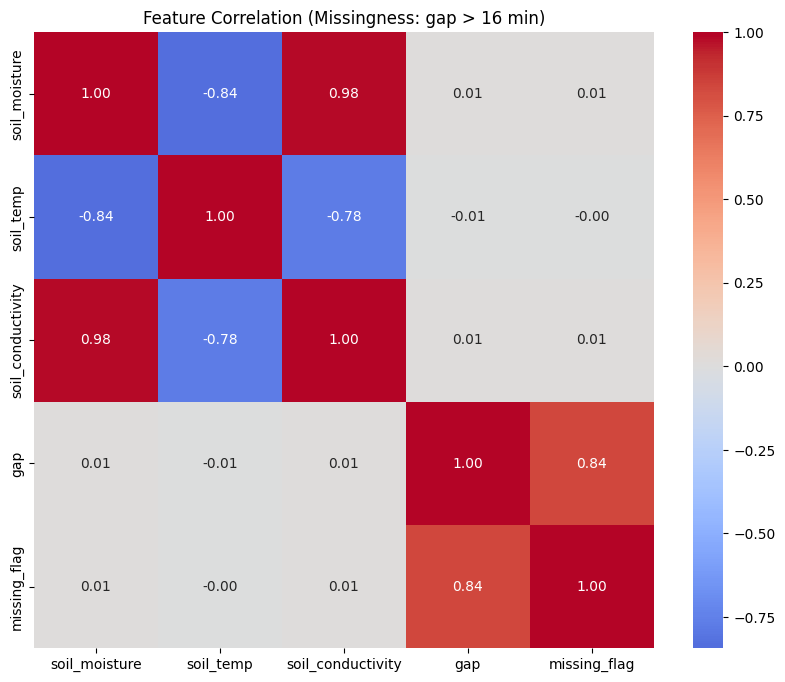

In [37]:
missing_feature_correlation(eden_theta)

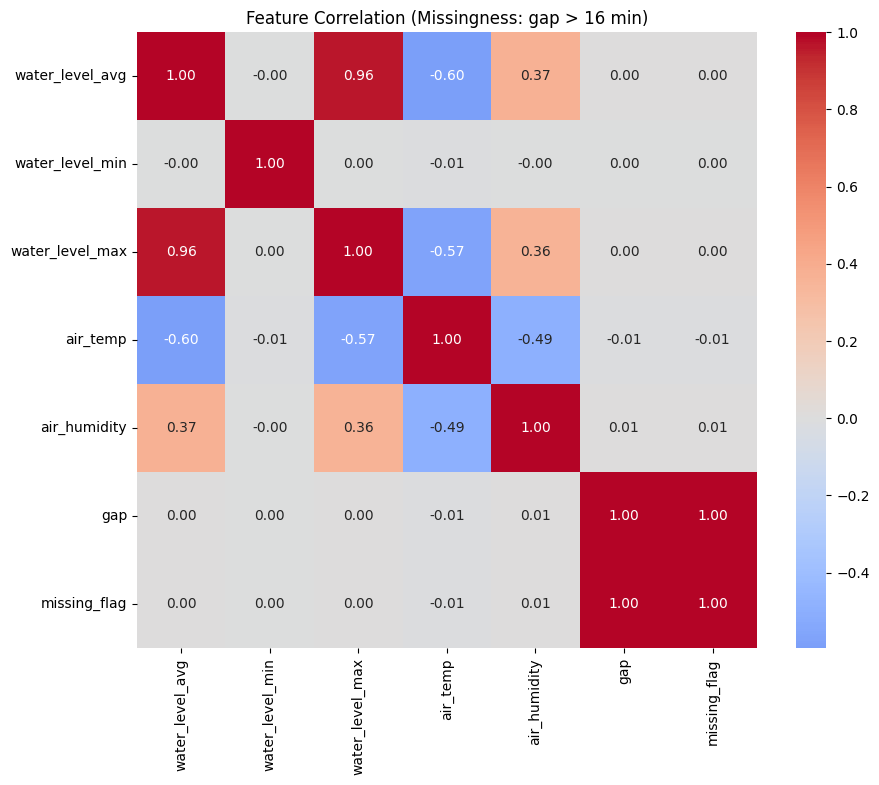

In [38]:
missing_feature_correlation(eden_hydro)

## Merging Train and Test Datasets

### Train

In [39]:
theta_merge = eden_theta.drop(columns=["device_eui", "device_name", "device_type", "site_name", "payload", "gap", "metadata"])
hydro_merge = eden_hydro.drop(columns=["device_name","device_eui","device_type","site_name","payload", "gap", "metadata"])

In [40]:
start = max(theta_merge["timestamp"].min(),
            hydro_merge["timestamp"].min())

end = min(theta_merge["timestamp"].max(),
          hydro_merge["timestamp"].max())

theta_merge = theta_merge[(theta_merge["timestamp"] >= start) & (theta_merge["timestamp"] <= end)]
hydro_merge = hydro_merge[(hydro_merge["timestamp"] >= start) & (hydro_merge["timestamp"] <= end)]

In [41]:
theta_merge

,timestamp,soil_moisture,soil_temp,soil_conductivity
0,2025-04-04 08:15:00+00:00,32.77,8.5,26.0
1,2025-04-04 08:30:00+00:00,32.76,8.5,26.0
2,2025-04-04 08:45:00+00:00,32.72,8.4,26.0
3,2025-04-04 09:00:00+00:00,32.77,8.4,26.0
4,2025-04-04 09:15:00+00:00,32.76,8.4,26.0
...,...,...,...,...
34267,2026-03-27 14:00:00+00:00,32.52,6.8,29.0
34268,2026-03-27 14:15:00+00:00,32.52,6.8,29.0
34269,2026-03-27 14:30:00+00:00,32.51,6.8,29.0
34270,2026-03-27 14:45:00+00:00,32.57,6.9,29.0


In [42]:
hydro_merge

,timestamp,water_level_avg,water_level_min,water_level_max,air_temp,air_humidity
741,2025-04-04 08:15:00+00:00,209.0,208.0,209.0,7.49,87.31
742,2025-04-04 08:30:00+00:00,207.0,205.0,208.0,7.70,86.28
743,2025-04-04 08:45:00+00:00,208.0,207.0,209.0,8.08,85.19
744,2025-04-04 09:00:00+00:00,207.0,204.0,209.0,8.12,85.03
745,2025-04-04 09:15:00+00:00,206.0,205.0,211.0,8.24,84.02
...,...,...,...,...,...,...
35009,2026-03-27 14:00:00+00:00,216.0,214.0,222.0,7.80,77.98
35010,2026-03-27 14:15:00+00:00,223.0,222.0,225.0,7.33,80.08
35011,2026-03-27 14:30:00+00:00,227.0,225.0,228.0,8.07,79.00
35012,2026-03-27 14:45:00+00:00,225.0,223.0,227.0,8.52,72.69


In [43]:
def add_missing_timestamps(df, timestamp_col="timestamp", freq="15min"):

    df_expanded = df.copy()
    df_expanded[timestamp_col] = pd.to_datetime(df_expanded[timestamp_col])
    df_expanded = df_expanded.sort_values(timestamp_col)
    df_expanded = df_expanded.drop_duplicates(subset=timestamp_col)
    df_expanded = df_expanded.set_index(timestamp_col)

    full_index = pd.date_range(
        start=df_expanded.index.min(),
        end=df_expanded.index.max(),
        freq=freq,
    )

    missing_timestamps = full_index.difference(df_expanded.index)

    df_expanded = (
        df_expanded.reindex(full_index)
        .rename_axis(timestamp_col)
        .reset_index()
    )

    missing_df = pd.DataFrame({timestamp_col: missing_timestamps})

    return df_expanded, missing_df


def interpolate_dataframe(df, timestamp_col="timestamp"):

    df_interp = df.copy()

    # Ensure timestamp is datetime
    df_interp[timestamp_col] = pd.to_datetime(df_interp[timestamp_col])

    # Set index for time-based interpolation
    df_interp = df_interp.set_index(timestamp_col)

    # Interpolate ONLY numeric columns, column-by-column
    for col in df_interp.select_dtypes(include=[np.number]).columns:
        df_interp[col] = df_interp[col].interpolate(
            method="time",
            limit_direction="both"
        )

    # Restore timestamp column
    df_interp = df_interp.reset_index()

    return df_interp

In [44]:
theta_merge_full, theta_missing_timestamps = add_missing_timestamps(
    theta_merge,
    timestamp_col="timestamp",
    freq="15min",
)

hydro_merge_full, hydro_missing_timestamps = add_missing_timestamps(
    hydro_merge,
    timestamp_col="timestamp",
    freq="15min",
)

theta_merge_interp = interpolate_dataframe(theta_merge_full, timestamp_col="timestamp")
hydro_merge_interp = interpolate_dataframe(hydro_merge_full, timestamp_col="timestamp")

print(f"Theta missing timestamps: {len(theta_missing_timestamps)}")
print(f"Hydro missing timestamps: {len(hydro_missing_timestamps)}")

merged_df = pd.merge(
    theta_merge_interp,
    hydro_merge_interp,
    on="timestamp",
    suffixes=("_hygro", "_droplet")
)

merged_df.to_csv("../data2/final_dataset.csv", index=False)

Theta missing timestamps: 28
Hydro missing timestamps: 27


In [45]:
theta_missing_timestamps

,timestamp
0,2025-04-21 01:15:00+00:00
1,2025-04-21 01:30:00+00:00
2,2025-04-21 01:45:00+00:00
3,2025-04-21 02:00:00+00:00
4,2025-04-21 02:15:00+00:00
5,2025-04-21 02:30:00+00:00
6,2025-04-21 02:45:00+00:00
7,2025-04-21 03:00:00+00:00
8,2025-04-21 03:15:00+00:00
9,2025-05-01 08:15:00+00:00


In [46]:
hydro_missing_timestamps

,timestamp
0,2026-01-16 00:00:00+00:00
1,2026-01-16 00:15:00+00:00
2,2026-01-16 00:30:00+00:00
3,2026-01-16 00:45:00+00:00
4,2026-01-16 01:00:00+00:00
5,2026-01-16 01:15:00+00:00
6,2026-01-16 01:30:00+00:00
7,2026-01-16 01:45:00+00:00
8,2026-01-16 02:00:00+00:00
9,2026-01-16 02:15:00+00:00


In [47]:
hydro_merge_full

,timestamp,water_level_avg,water_level_min,water_level_max,air_temp,air_humidity
0,2025-04-04 08:15:00+00:00,209.0,208.0,209.0,7.49,87.31
1,2025-04-04 08:30:00+00:00,207.0,205.0,208.0,7.70,86.28
2,2025-04-04 08:45:00+00:00,208.0,207.0,209.0,8.08,85.19
3,2025-04-04 09:00:00+00:00,207.0,204.0,209.0,8.12,85.03
4,2025-04-04 09:15:00+00:00,206.0,205.0,211.0,8.24,84.02
...,...,...,...,...,...,...
34295,2026-03-27 14:00:00+00:00,216.0,214.0,222.0,7.80,77.98
34296,2026-03-27 14:15:00+00:00,223.0,222.0,225.0,7.33,80.08
34297,2026-03-27 14:30:00+00:00,227.0,225.0,228.0,8.07,79.00
34298,2026-03-27 14:45:00+00:00,225.0,223.0,227.0,8.52,72.69


In [48]:
theta_merge_full

,timestamp,soil_moisture,soil_temp,soil_conductivity
0,2025-04-04 08:15:00+00:00,32.77,8.5,26.0
1,2025-04-04 08:30:00+00:00,32.76,8.5,26.0
2,2025-04-04 08:45:00+00:00,32.72,8.4,26.0
3,2025-04-04 09:00:00+00:00,32.77,8.4,26.0
4,2025-04-04 09:15:00+00:00,32.76,8.4,26.0
...,...,...,...,...
34295,2026-03-27 14:00:00+00:00,32.52,6.8,29.0
34296,2026-03-27 14:15:00+00:00,32.52,6.8,29.0
34297,2026-03-27 14:30:00+00:00,32.51,6.8,29.0
34298,2026-03-27 14:45:00+00:00,32.57,6.9,29.0


In [49]:
merged_df

,timestamp,soil_moisture,soil_temp,soil_conductivity,water_level_avg,water_level_min,water_level_max,air_temp,air_humidity
0,2025-04-04 08:15:00+00:00,32.77,8.5,26.0,209.0,208.0,209.0,7.49,87.31
1,2025-04-04 08:30:00+00:00,32.76,8.5,26.0,207.0,205.0,208.0,7.70,86.28
2,2025-04-04 08:45:00+00:00,32.72,8.4,26.0,208.0,207.0,209.0,8.08,85.19
3,2025-04-04 09:00:00+00:00,32.77,8.4,26.0,207.0,204.0,209.0,8.12,85.03
4,2025-04-04 09:15:00+00:00,32.76,8.4,26.0,206.0,205.0,211.0,8.24,84.02
...,...,...,...,...,...,...,...,...,...
34295,2026-03-27 14:00:00+00:00,32.52,6.8,29.0,216.0,214.0,222.0,7.80,77.98
34296,2026-03-27 14:15:00+00:00,32.52,6.8,29.0,223.0,222.0,225.0,7.33,80.08
34297,2026-03-27 14:30:00+00:00,32.51,6.8,29.0,227.0,225.0,228.0,8.07,79.00
34298,2026-03-27 14:45:00+00:00,32.57,6.9,29.0,225.0,223.0,227.0,8.52,72.69
